In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

Read the Dataset

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Breast Cancer METABRIC.csv')
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


Check dataset Info and drop useless columns

In [8]:
data.drop(['Patient ID','Relapse Free Status (Months)','Overall Survival (Months)'], axis=1, inplace=True)
data.info()
data.drop_duplicates(inplace=True)
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age at Diagnosis                1985 non-null   float64
 1   Type of Breast Surgery          1955 non-null   object 
 2   Cancer Type                     1985 non-null   object 
 3   Cancer Type Detailed            1985 non-null   object 
 4   Cellularity                     1917 non-null   object 
 5   Chemotherapy                    1980 non-null   object 
 6   Pam50 + Claudin-low subtype     1980 non-null   object 
 7   Cohort                          1985 non-null   int64  
 8   ER status measured by IHC       1942 non-null   object 
 9   ER Status                       1985 non-null   object 
 10  Neoplasm Histologic Grade       1897 non-null   float64
 11  HER2 status measured by SNP6    1980 non-null   object 
 12  HER2 Status                     19

(1985, 31)

Split the Data

In [9]:
from sklearn.model_selection import train_test_split

x=data.drop('Relapse Free Status',axis=1)
y=data['Relapse Free Status']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((1588, 30), (397, 30))

Handel Null values in categorical columns

In [10]:
for i in x_train.columns:
   if x_train[i].dtype == 'object':
     if x_train[i].isnull().sum() < 70:
       x_train[i].fillna(x_train[i].mode()[0], inplace=True)
       x_test[i].fillna(x_train[i].mode()[0], inplace=True)

x_train['Primary Tumor Laterality'].fillna('Unknown', inplace=True)
x_train['3-Gene classifier subtype'].fillna('Unknown', inplace=True)

x_test['Primary Tumor Laterality'].fillna('Unknown', inplace=True)
x_test['3-Gene classifier subtype'].fillna('Unknown', inplace=True)

data.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,Living,Negative,Yes,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,Living,Positive,Yes,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,Deceased,Positive,No,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,Living,Positive,Yes,Not Recurred,Female,NaN,25.0,2.0,Living
4,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,Deceased,Positive,Yes,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


Handel Null values in Numeric columns

Neoplasm Histologic Grade 88
Lymph nodes examined positive 76
Mutation Count 121
Nottingham prognostic index 1
Tumor Size 26
Tumor Stage 515


(Age at Diagnosis                  0
 Type of Breast Surgery            0
 Cancer Type                       0
 Cancer Type Detailed              0
 Cellularity                       0
 Chemotherapy                      0
 Pam50 + Claudin-low subtype       0
 Cohort                            0
 ER status measured by IHC         0
 ER Status                         0
 Neoplasm Histologic Grade         0
 HER2 status measured by SNP6      0
 HER2 Status                       0
 Tumor Other Histologic Subtype    0
 Hormone Therapy                   0
 Inferred Menopausal State         0
 Integrative Cluster               0
 Primary Tumor Laterality          0
 Lymph nodes examined positive     0
 Mutation Count                    0
 Nottingham prognostic index       0
 Oncotree Code                     0
 Overall Survival Status           0
 PR Status                         0
 Radio Therapy                     0
 Sex                               0
 3-Gene classifier subtype         0
 

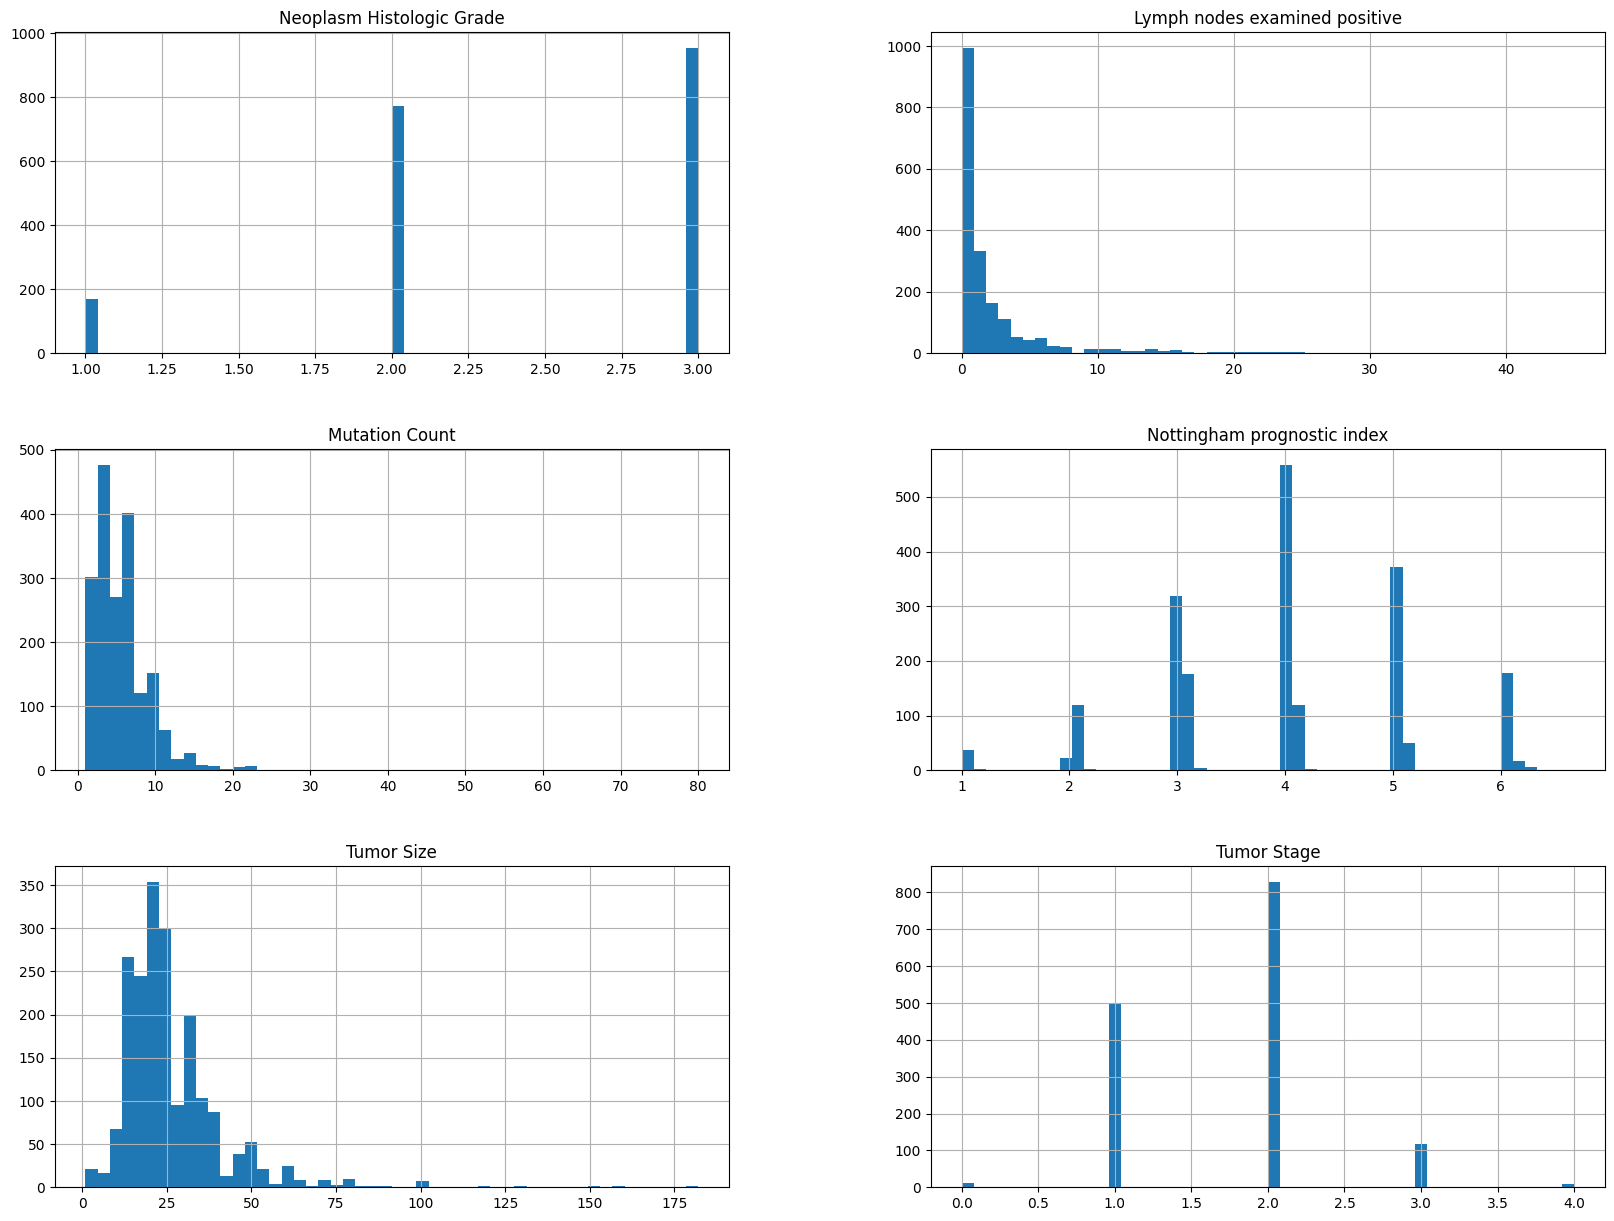

In [11]:
n=[]
for i in data.columns:
  if data[i].dtype != 'object':
    if data[i].isnull().sum() > 0:
      print(i,data[i].isnull().sum())
      n.append(i)



data[n].hist(bins=50, figsize=(20,15))


x_train['Neoplasm Histologic Grade'].fillna(x_train['Neoplasm Histologic Grade'].mode()[0], inplace=True)
x_train['Tumor Stage'].fillna(x_train['Tumor Stage'].mode()[0], inplace=True)
x_train['Lymph nodes examined positive'].fillna(x_train['Lymph nodes examined positive'].median(), inplace=True)
x_train['Mutation Count'].fillna(x_train['Mutation Count'].median(), inplace=True)
x_train['Nottingham prognostic index'].fillna(x_train['Nottingham prognostic index'].mean(), inplace=True)
x_train['Tumor Size'].fillna(x_train['Tumor Size'].median(), inplace=True)

x_test['Neoplasm Histologic Grade'].fillna(x_train['Neoplasm Histologic Grade'].mode()[0], inplace=True)
x_test['Tumor Stage'].fillna(x_train['Tumor Stage'].mode()[0], inplace=True)
x_test['Lymph nodes examined positive'].fillna(x_train['Lymph nodes examined positive'].median(), inplace=True)
x_test['Mutation Count'].fillna(x_train['Mutation Count'].median(), inplace=True)
x_test['Nottingham prognostic index'].fillna(x_train['Nottingham prognostic index'].mean(), inplace=True)
x_test['Tumor Size'].fillna(x_train['Tumor Size'].median(), inplace=True)

y_train.dropna(axis=0,inplace=True)
y_train.reset_index()
x_train=x_train.loc[y_train.index]

x_train.isnull().sum(),x_test.isnull().sum(),

Column names for emnedding layers

In [12]:
e=[]
for i in x_train.columns:
   if x_train[i].dtype == 'object':
    if len(data[i].unique()) > 4:
     e.append(i)

e

['Cancer Type Detailed',
 'Pam50 + Claudin-low subtype',
 'HER2 status measured by SNP6',
 'Tumor Other Histologic Subtype',
 'Integrative Cluster',
 'Oncotree Code',
 '3-Gene classifier subtype']

Get numerical and categorical column names

In [13]:
g=[]
for i in x_train.columns:
  if i not in n:
    g.append(i)

cat_col=[]
num_col=[]
for i in x_train.columns:
  if x_train[i].dtype == 'object':
    cat_col.append(i)
  else:
    num_col.append(i)


Encode categorical columns

In [14]:
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

L=LabelEncoder()

d={'1':1,'2':2,'3':3,'4ER-':3.9,'4ER+':4.1,'5':5,'6':6,'7':7,'8':8,'9':9,'10':10}
x_train['Integrative Cluster']=x_train['Integrative Cluster'].map(d).astype('float')
x_test['Integrative Cluster']=x_test['Integrative Cluster'].map(d).astype('float')

for i in x_train.columns:
   l=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
   if x_train[i].dtype == 'object':
    x_train[i]=l.fit_transform(x_train[[i]])
    x_test[i]=l.transform(x_test[[i]])

y_train=L.fit_transform(y_train).astype('float')
y_test=L.transform(y_test)

In [15]:
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
x_train.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival Status,PR Status,Radio Therapy,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,49.50,1.0,0.0,2.0,0.0,0.0,3.0,2,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,8.0,0.0,0.0,6.0,3.064,2.0,1.0,1.0,0.0,0.0,0.0,32.0,1.0,2.0
1,26.36,0.0,0.0,2.0,0.0,0.0,2.0,1,1.0,1.0,3.0,2.0,0.0,0.0,1.0,1.0,6.0,1.0,0.0,1.0,4.024,2.0,0.0,1.0,1.0,0.0,0.0,12.0,1.0,0.0
2,63.10,0.0,0.0,2.0,2.0,0.0,3.0,2,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,7.0,1.0,2.0,4.0,4.030,2.0,0.0,1.0,1.0,0.0,1.0,15.0,2.0,0.0
3,85.39,0.0,0.0,2.0,0.0,0.0,2.0,1,1.0,1.0,3.0,2.0,0.0,0.0,1.0,0.0,9.0,1.0,2.0,7.0,5.044,2.0,0.0,0.0,1.0,0.0,0.0,22.0,2.0,1.0
4,37.01,1.0,0.0,2.0,0.0,1.0,1.0,2,0.0,0.0,3.0,0.0,1.0,0.0,0.0,1.0,5.0,1.0,5.0,6.0,6.074,2.0,0.0,0.0,1.0,0.0,3.0,37.0,3.0,0.0


Apply StandardScaler only to the numerical columns

In [16]:
from sklearn.preprocessing import StandardScaler

s=StandardScaler()

x_train[num_col]=s.fit_transform(x_train[num_col])
x_test[num_col]=s.transform(x_test[num_col])

Model definition

In [17]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Input,Embedding,Dense,Flatten,Concatenate,Dropout,BatchNormalization

input_c=Input(shape=(1,))
input_p=Input(shape=(1,))
input_h=Input(shape=(1,))
input_t=Input(shape=(1,))
input_i=Input(shape=(1,))
input_o=Input(shape=(1,))
input_3=Input(shape=(1,))
input_g=Input(shape=(len(g),))

embed_c=Embedding(input_dim=11,output_dim=5)
out_c=embed_c(input_c)
embed_p=Embedding(input_dim=11,output_dim=5)
out_p=embed_p(input_p)
embed_h=Embedding(input_dim=11,output_dim=5)
out_h=embed_h(input_h)
embed_t=Embedding(input_dim=11,output_dim=5)
out_t=embed_t(input_t)
embed_i=Embedding(input_dim=11,output_dim=5)
out_i=embed_i(input_i)
embed_o=Embedding(input_dim=11,output_dim=5)
out_o=embed_o(input_o)
embed_3=Embedding(input_dim=11,output_dim=5)
out_3=embed_3(input_3)
embed_g=Embedding(input_dim=11,output_dim=5)
out_g=embed_g(input_g)

flatten_layer=Flatten()

fl_c=flatten_layer(out_c)
fl_p=flatten_layer(out_p)
fl_h=flatten_layer(out_h)
fl_t=flatten_layer(out_t)
fl_i=flatten_layer(out_i)
fl_o=flatten_layer(out_o)
fl_3=flatten_layer(out_3)
fl_g=flatten_layer(out_g)

concat_layer=Concatenate()
concat=concat_layer([fl_c,fl_p,fl_h,fl_t,fl_i,fl_o,fl_3,fl_g])

d1=Dense(200,activation='relu')
b1=BatchNormalization()
dr1=Dropout(0.5)
d2=Dense(200,activation='relu')
b2=BatchNormalization()
dr2=Dropout(0.5)
d3=Dense(200,activation='relu')
b3=BatchNormalization()
dr3=Dropout(0.5)
d4=Dense(200,activation='relu')
b4=BatchNormalization()
dr4=Dropout(0.5)
out_put=Dense(1,activation='sigmoid')

d1_out=d1(concat)
d1_out=b1(d1_out)
d1_out=dr1(d1_out)
d2_out=d2(d1_out)
d2_out=b2(d2_out)
d2_out=dr2(d2_out)
d3_out=d3(d2_out)
d3_out=b3(d3_out)
d3_out=dr3(d3_out)
d4_out=d4(d3_out)
d4_out=b4(d4_out)
d4_out=dr4(d4_out)
out=out_put(d4_out)

model=Model(inputs=[input_c,input_p,input_h,input_t,input_i,input_o,input_3,input_g],outputs=out)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

x_train_input=[x_train['Cancer Type Detailed'].values,x_train['Pam50 + Claudin-low subtype'].values,
            x_train['HER2 status measured by SNP6'].values,x_train['Tumor Other Histologic Subtype'].values,
            x_train['Integrative Cluster'].values,x_train['Oncotree Code'].values,
            x_train['3-Gene classifier subtype'].values,x_train[g].values]

model.fit(x=x_train_input,y=y_train,epochs=35,batch_size=60)
model.summary()

Epoch 1/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.5406 - loss: 0.9504
Epoch 2/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6616 - loss: 0.7209
Epoch 3/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7940 - loss: 0.4758
Epoch 4/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8683 - loss: 0.3869
Epoch 5/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8853 - loss: 0.3514
Epoch 6/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8929 - loss: 0.3288
Epoch 7/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9042 - loss: 0.3000
Epoch 8/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8922 - loss: 0.3018
Epoch 9/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8998 - loss: 0.2851
Epoch 10/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9042 - loss: 0.2883
Epoch 11/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9118 - loss: 0.2676
Epoch 12/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9105 -

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 5)      │         55 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 5)      │         55 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 5)      │         55 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 5)      │         55 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 5)      │         55 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 5)      │         55 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 5)      │         55 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 24, 5)     │         55 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 120)       │          0 │ embedding[0][0],

 Total params: 463,725 (1.77 MB)

 Trainable params: 154,041 (601.72 KB)

 Non-trainable params: 1,600 (6.25 KB)

 Optimizer params: 308,084 (1.18 MB)

Model Evaluation

In [18]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,recall_score,precision_score,roc_auc_score,RocCurveDisplay,ConfusionMatrixDisplay
from google.colab import files

x_test_input=[x_test['Cancer Type Detailed'].values,x_test['Pam50 + Claudin-low subtype'].values,
            x_test['HER2 status measured by SNP6'].values,x_test['Tumor Other Histologic Subtype'].values,
            x_test['Integrative Cluster'].values,x_test['Oncotree Code'].values,
            x_test['3-Gene classifier subtype'].values,x_test[g].values]


y_pred_prob=model.predict(x_test_input)
y_pred = (y_pred_prob > 0.4).astype(int)
ac=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
pr=precision_score(y_test,y_pred)
re=recall_score(y_test,y_pred)
au=roc_auc_score(y_test,y_pred_prob)

print(f"AUC: {au}")
print(f"Recall: {re}")
print(f"Precision: {pr}")
print(f"Accuracy: {ac}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix:\n{cm}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
AUC: 0.9064270960224565
Recall: 0.7848101265822784
Precision: 1.0
Accuracy: 0.9143576826196473
F1 Score: 0.8794326241134752
Confusion Matrix:
[[239   0]
 [ 34 124]]


Visualization

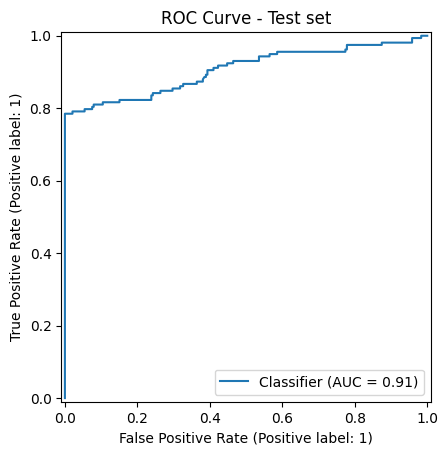

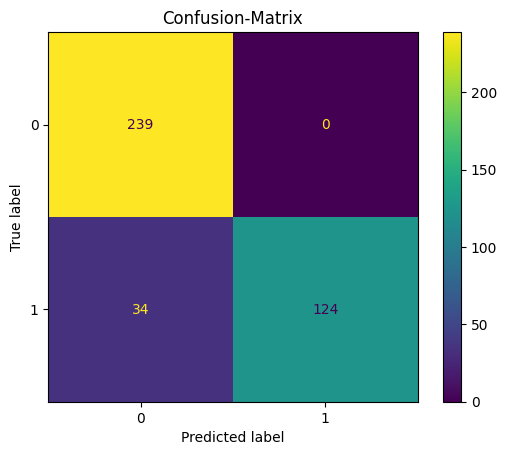

In [19]:
RocCurveDisplay.from_predictions(y_test,y_pred_prob)
plt.title('ROC Curve - Test set')
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title('Confusion-Matrix')
plt.show()